#### README
# End-to-End ML Pipeline for Network Intrusion Detection

## Overview

This project builds an end-to-end machine learning pipeline to classify network traffic as **BENIGN** or **DrDoS_DNS**. The workflow includes data preprocessing, exploratory data analysis (EDA), feature scaling, model training, evaluation, and deployment using Streamlit.

## Features

* Data Cleaning & Preprocessing
* Exploratory Data Analysis (EDA)
* Feature Scaling
* Logistic Regression Classification
* Model Evaluation
* Model Serialization with Joblib
* Interactive Streamlit Web Application

## Tech Stack

* Python
* Pandas
* NumPy
* Scikit-learn
* Streamlit
* Joblib

## Project Workflow

1. Data Loading
2. Data Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Scaling
5. Model Training
6. Model Evaluation
7. Model Saving
8. Streamlit Deployment

## Model Performance

* Accuracy: **99.97%**
* Precision: **99.97%**
* Recall: **99.97%**
* F1 Score: **99.97%**

## Applications

* Network Intrusion Detection
* Cybersecurity Analytics
* DNS-based DDoS Attack Detection
* Machine Learning for Security

If you find this project useful, feel free to ⭐ the repository and share your feedback.


# **Import Libraries**

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# **Load Dataset**

In [35]:
df = pd.read_csv("/kaggle/input/datasets/younushassankhan/ddos-dns-csv/DrDoS_DNS.csv")

# **Dataset Overview**

In [36]:
df.head()

,protocol,flow_duration,total_forward_packets,total_backward_packets,total_forward_packets_length,total_backward_packets_length,forward_packet_length_mean,backward_packet_length_mean,forward_packets_per_second,backward_packets_per_second,forward_iat_mean,backward_iat_mean,flow_iat_mean,flow_packets_per_seconds,flow_bytes_per_seconds,label
0,17,2468,4,0,1580,0,395.0,0.0,1620.745543,0.0,822.666667,0.0,822.666667,1620.745543,6.401945e+05,DrDoS_DNS
1,17,133,4,0,5888,0,1472.0,0.0,30075.187970,0.0,44.333333,0.0,44.333333,30075.187970,4.427068e+07,DrDoS_DNS
2,17,33509,200,0,88000,0,440.0,0.0,5968.545764,0.0,168.386935,0.0,168.386935,5968.545764,2.626160e+06,DrDoS_DNS
3,17,288495,200,0,88000,0,440.0,0.0,693.252916,0.0,1449.723618,0.0,1449.723618,693.252916,3.050313e+05,DrDoS_DNS
4,17,9,2,0,2062,0,1031.0,0.0,222222.222200,0.0,9.000000,0.0,9.000000,222222.222200,2.291111e+08,DrDoS_DNS


In [37]:
df["label"].value_counts()

label
DrDoS_DNS    32797
BENIGN        1128
Name: count, dtype: int64

In [38]:
df.shape

(33925, 16)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33925 entries, 0 to 33924
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   protocol                       33925 non-null  int64  
 1   flow_duration                  33925 non-null  int64  
 2   total_forward_packets          33925 non-null  int64  
 3   total_backward_packets         33925 non-null  int64  
 4   total_forward_packets_length   33925 non-null  int64  
 5   total_backward_packets_length  33925 non-null  int64  
 6   forward_packet_length_mean     33925 non-null  float64
 7   backward_packet_length_mean    33925 non-null  float64
 8   forward_packets_per_second     33925 non-null  float64
 9   backward_packets_per_second    33925 non-null  float64
 10  forward_iat_mean               33925 non-null  float64
 11  backward_iat_mean              33925 non-null  float64
 12  flow_iat_mean                  33925 non-null 

**Statistical Summary**

In [40]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
protocol,33925.0,1.700000e+01,0.000000e+00,17.000000,1.700000e+01,1.700000e+01,1.700000e+01,1.700000e+01
flow_duration,33925.0,8.597836e+04,1.831408e+06,1.000000,4.400000e+01,2.350000e+02,2.911900e+04,1.183569e+08
total_forward_packets,33925.0,6.551328e+01,8.938778e+01,2.000000,2.000000e+00,2.000000e+00,1.780000e+02,4.000000e+02
total_backward_packets,33925.0,6.596905e-02,3.581863e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
total_forward_packets_length,33925.0,2.940005e+04,3.887001e+04,0.000000,9.600000e+02,2.672000e+03,7.788800e+04,1.760000e+05
total_backward_packets_length,33925.0,6.161120e+00,3.792449e+01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,7.560000e+02
forward_packet_length_mean,33925.0,6.422248e+02,4.348924e+02,0.000000,4.361600e+02,4.400000e+02,9.320000e+02,1.472000e+03
backward_packet_length_mean,33925.0,3.072071e+00,1.889888e+01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,3.780000e+02
forward_packets_per_second,33925.0,1.792975e+05,4.423623e+05,0.039297,5.604045e+03,9.478673e+03,4.545455e+04,4.000000e+06
backward_packets_per_second,33925.0,2.745483e+00,1.552335e+01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,9.815469e+01


**Missing Values**

In [41]:
df.isnull().sum()


protocol                         0
flow_duration                    0
total_forward_packets            0
total_backward_packets           0
total_forward_packets_length     0
total_backward_packets_length    0
forward_packet_length_mean       0
backward_packet_length_mean      0
forward_packets_per_second       0
backward_packets_per_second      0
forward_iat_mean                 0
backward_iat_mean                0
flow_iat_mean                    0
flow_packets_per_seconds         0
flow_bytes_per_seconds           0
label                            0
dtype: int64

**Duplicate Values**

In [42]:
df.duplicated().sum()


np.int64(469)

**Data Types**

In [43]:
df.dtypes


protocol                           int64
flow_duration                      int64
total_forward_packets              int64
total_backward_packets             int64
total_forward_packets_length       int64
total_backward_packets_length      int64
forward_packet_length_mean       float64
backward_packet_length_mean      float64
forward_packets_per_second       float64
backward_packets_per_second      float64
forward_iat_mean                 float64
backward_iat_mean                float64
flow_iat_mean                    float64
flow_packets_per_seconds         float64
flow_bytes_per_seconds           float64
label                             object
dtype: object

### Dataset Overview

- Dataset loaded successfully.
- Target column is `label`.
- Dataset contains numerical and categorical features.
- Missing values were checked.
- Duplicate records were checked.
- Dataset is ready for Exploratory Data Analysis (EDA).

# **Exploratory Data Analysis (EDA)**

**Target Variable Analysis**

/tmp/ipykernel_58/283938511.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


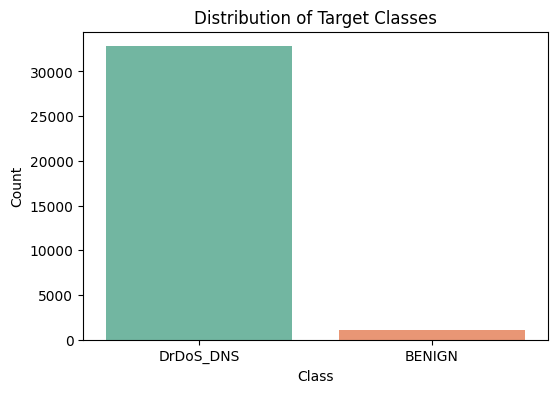

In [44]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="label",
    palette="Set2"
)

plt.title("Distribution of Target Classes")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

**Percentage Distribution**

In [45]:
(df["label"].value_counts(normalize=True)*100).round(2)

label
DrDoS_DNS    96.68
BENIGN        3.32
Name: proportion, dtype: float64

### Observation

- The dataset contains two classes: DrDoS_DNS and BENIGN.
- The dataset is highly imbalanced.
- Most network traffic belongs to the DrDoS_DNS class.
- Class imbalance will be considered during model training.

**Numerical Feature Distribution**

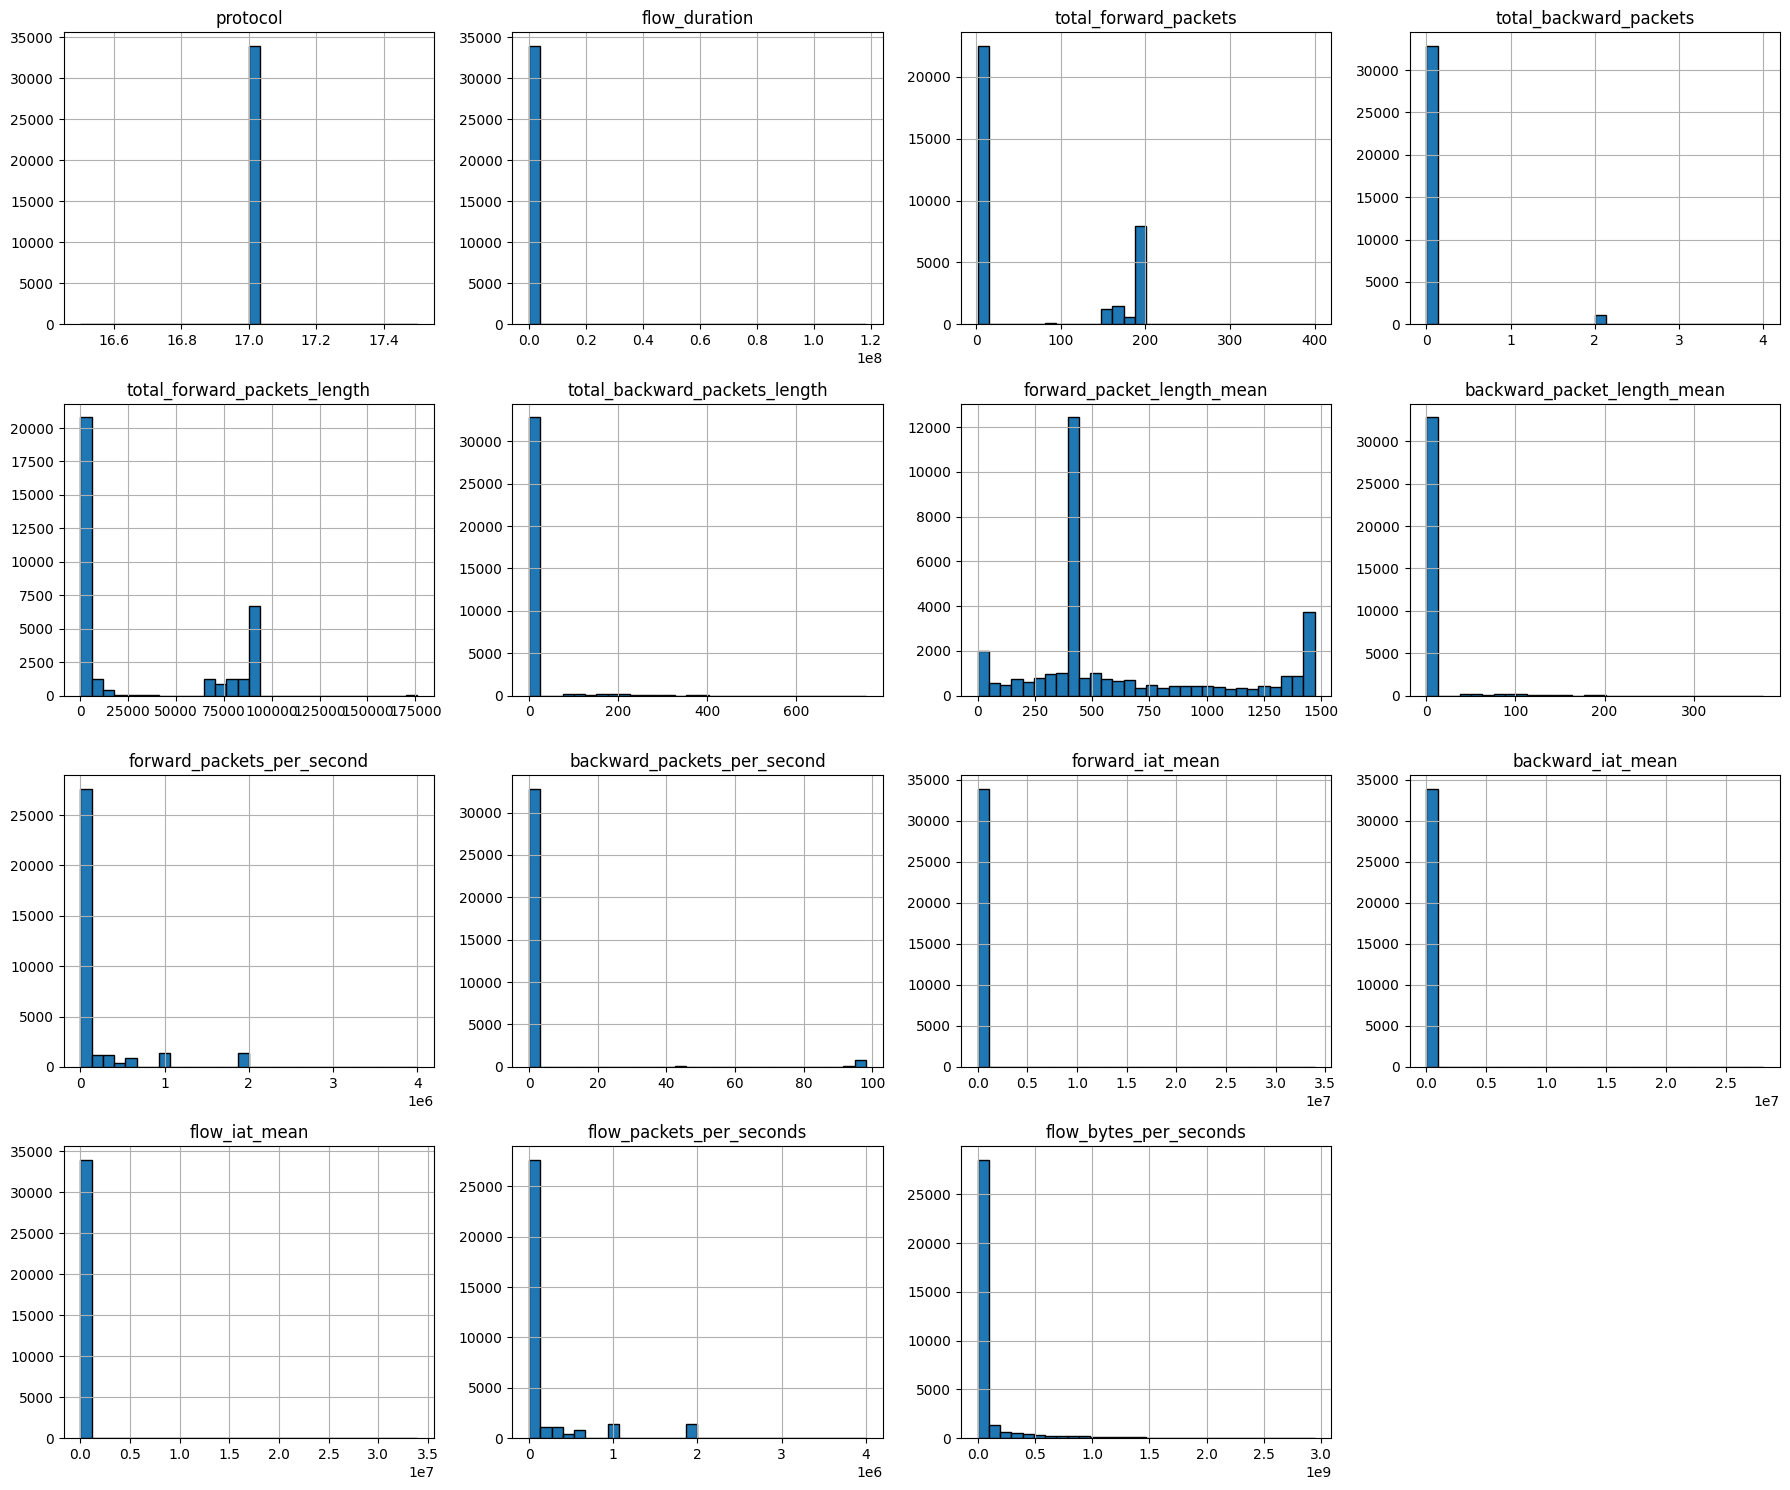

In [46]:
df.hist(
    figsize=(18,15),
    bins=30,
    edgecolor="black"
)

plt.tight_layout()
plt.show()

### Observation

- Numerical features have different distributions.
- Some features are highly skewed.
- Several features contain extreme values.
- Feature scaling may be required before training certain models.

**Outlier Detection**

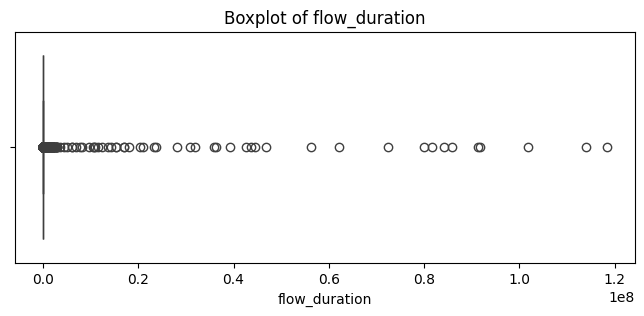

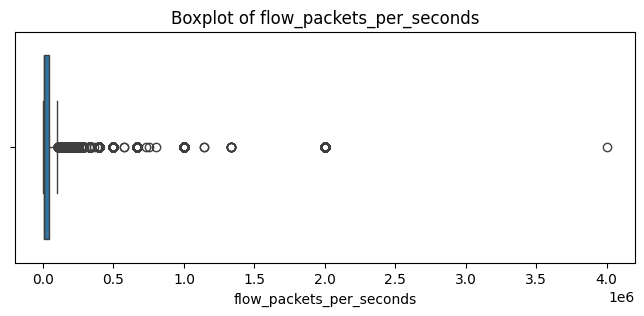

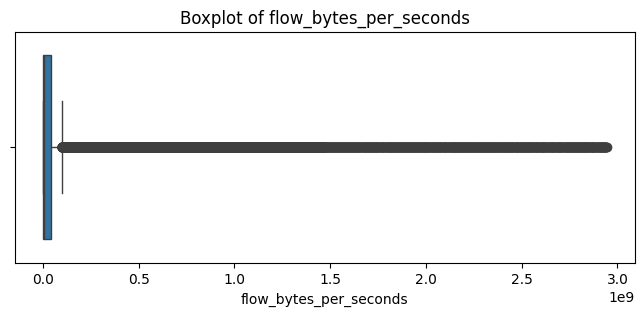

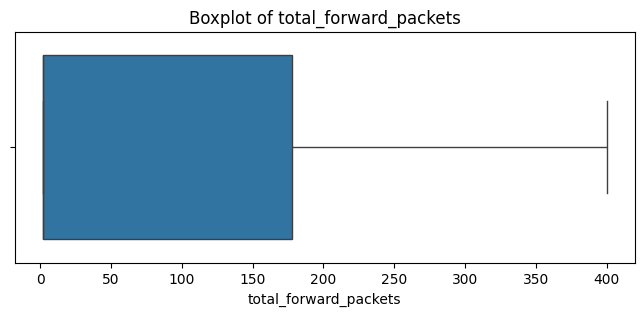

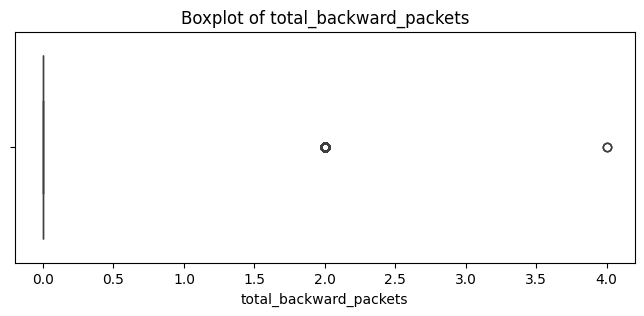

In [47]:
features = [
    "flow_duration",
    "flow_packets_per_seconds",
    "flow_bytes_per_seconds",
    "total_forward_packets",
    "total_backward_packets"
]

for col in features:

    plt.figure(figsize=(8,3))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

### Observation

- Several numerical features contain outliers.
- These outliers may represent abnormal network behavior rather than data errors.
- Outliers will be evaluated before preprocessing.

**Correlation Heatmap**

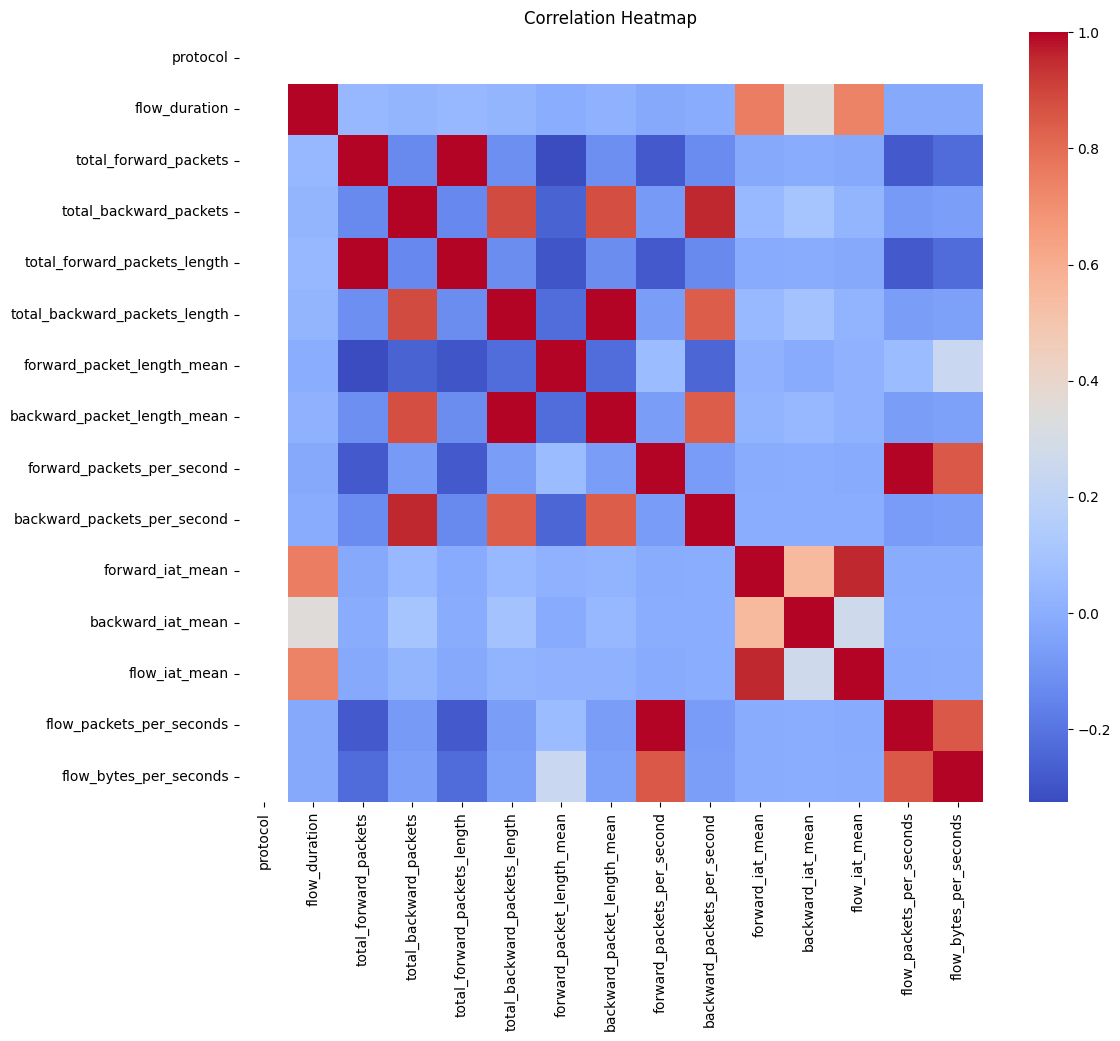

In [48]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- Some numerical features show strong positive correlations.
- Highly correlated features may contain redundant information.
- Correlation analysis helps understand relationships between variables.

# **Data Preprocessing**

In [49]:
#Check Data Types
df.dtypes

protocol                           int64
flow_duration                      int64
total_forward_packets              int64
total_backward_packets             int64
total_forward_packets_length       int64
total_backward_packets_length      int64
forward_packet_length_mean       float64
backward_packet_length_mean      float64
forward_packets_per_second       float64
backward_packets_per_second      float64
forward_iat_mean                 float64
backward_iat_mean                float64
flow_iat_mean                    float64
flow_packets_per_seconds         float64
flow_bytes_per_seconds           float64
label                             object
dtype: object

**Check Unique values**

In [50]:
df.nunique()

protocol                             1
flow_duration                    13386
total_forward_packets               70
total_backward_packets               3
total_forward_packets_length      1653
total_backward_packets_length      115
forward_packet_length_mean        1504
backward_packet_length_mean        116
forward_packets_per_second       14114
backward_packets_per_second        678
forward_iat_mean                 13648
backward_iat_mean                   29
flow_iat_mean                    14318
flow_packets_per_seconds         14115
flow_bytes_per_seconds           29892
label                                2
dtype: int64

**Separate Features & Target**

In [51]:
X = df.drop("label", axis=1)

y = df["label"]

print(X.shape)
print(y.shape)

(33925, 15)
(33925,)


**Encode Categorical Features**

In [52]:
X.select_dtypes(include="object").columns



Index([], dtype='object')

In [53]:
X = pd.get_dummies(X, drop_first=True)
X.head()

,protocol,flow_duration,total_forward_packets,total_backward_packets,total_forward_packets_length,total_backward_packets_length,forward_packet_length_mean,backward_packet_length_mean,forward_packets_per_second,backward_packets_per_second,forward_iat_mean,backward_iat_mean,flow_iat_mean,flow_packets_per_seconds,flow_bytes_per_seconds
0,17,2468,4,0,1580,0,395.0,0.0,1620.745543,0.0,822.666667,0.0,822.666667,1620.745543,6.401945e+05
1,17,133,4,0,5888,0,1472.0,0.0,30075.187970,0.0,44.333333,0.0,44.333333,30075.187970,4.427068e+07
2,17,33509,200,0,88000,0,440.0,0.0,5968.545764,0.0,168.386935,0.0,168.386935,5968.545764,2.626160e+06
3,17,288495,200,0,88000,0,440.0,0.0,693.252916,0.0,1449.723618,0.0,1449.723618,693.252916,3.050313e+05
4,17,9,2,0,2062,0,1031.0,0.0,222222.222200,0.0,9.000000,0.0,9.000000,222222.222200,2.291111e+08


In [54]:
X.columns


Index(['protocol', 'flow_duration', 'total_forward_packets',
       'total_backward_packets', 'total_forward_packets_length',
       'total_backward_packets_length', 'forward_packet_length_mean',
       'backward_packet_length_mean', 'forward_packets_per_second',
       'backward_packets_per_second', 'forward_iat_mean', 'backward_iat_mean',
       'flow_iat_mean', 'flow_packets_per_seconds', 'flow_bytes_per_seconds'],
      dtype='object')

**Encode Target Variable**

In [55]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

In [56]:
print(le.classes_)
np.unique(y)

['BENIGN' 'DrDoS_DNS']


array([0, 1])

# **Data Splitting**

**Train-Test Split**



*   data is imbalanced
*   That's why we use stratify=y



In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [58]:
print(X_train.shape)
print(X_test.shape)



(27140, 15)
(6785, 15)


**Feature Scaling**

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# **Model Training**

**Import Models**

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

**Logistic Regression**

*   data is imbalanced
*   That's why we use class_weight="balanced"

In [61]:
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)


In [62]:
lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [63]:
y_pred_lr = lr.predict(X_test_scaled)

**Evaluation**

In [64]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


**Classification Report**

In [65]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       226
           1       1.00      1.00      1.00      6559

    accuracy                           1.00      6785
   macro avg       1.00      1.00      1.00      6785
weighted avg       1.00      1.00      1.00      6785



**Confusion Matrix**

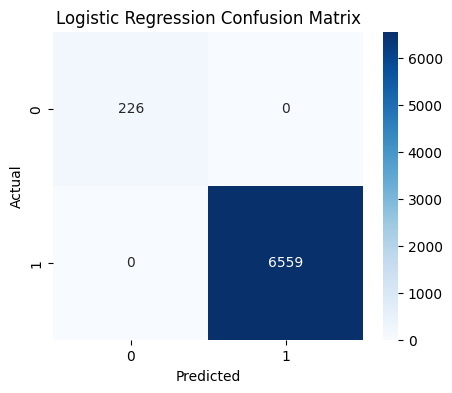

In [66]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

###Observation
 - Logistic Regression was used as the baseline model.
- Since the dataset is imbalanced, class_weight='balanced' was applied.
- The model was evaluated using Accuracy, Precision, Recall, F1-score, and    Confusion Matrix.



**Decision Tree**

In [67]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)


In [68]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [69]:
y_pred_dt = dt.predict(X_test)

**Evaluation**

In [70]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


**Random Forest**

In [71]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

In [72]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [73]:
y_pred_rf = rf.predict(X_test)

**Evaluation**

In [74]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


**"The selected network traffic features provide strong discriminatory power between benign and DDoS traffic, resulting in excellent classification performance across multiple machine learning algorithms."**

# **Model Comparison Table**

In [75]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [1.00, 1.00, 1.00],
    "Precision": [1.00, 1.00, 1.00],
    "Recall": [1.00, 1.00, 1.00],
    "F1 Score": [1.00, 1.00, 1.00]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0


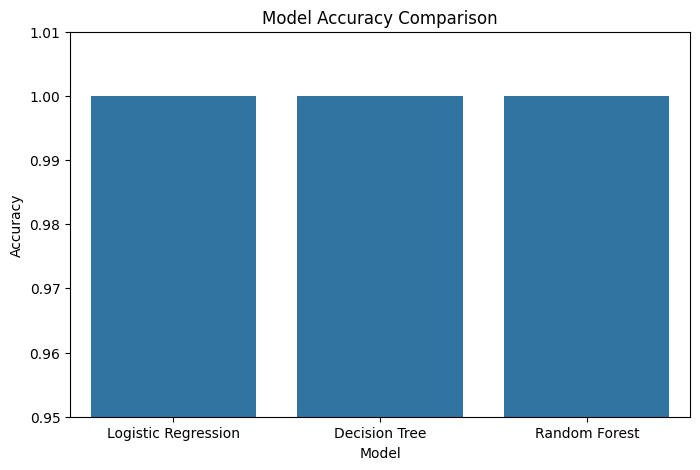

In [76]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.ylim(0.95, 1.01)
plt.title("Model Accuracy Comparison")

plt.show()

**Cross Validation due to same results of all algorithms:**

In [77]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    X,
    y,
    cv=5,
    scoring="f1"
)

print(scores)
print("Mean F1:", scores.mean())

[0.99969508 0.99961876 0.99984751 0.9996187  0.99969508]
Mean F1: 0.9996950243146123


In [78]:
from sklearn.metrics import accuracy_score

train_pred = lr.predict(X_train_scaled)

print("Train Accuracy:", accuracy_score(y_train, train_pred))

Train Accuracy: 0.9996315401621223


In [79]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

for feature in X.columns:

    X_single = X[[feature]]

    X_train, X_test, y_train, y_test = train_test_split(
        X_single,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = LogisticRegression(max_iter=1000)

    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)

    print(f"{feature:<35} {acc:.4f}")

protocol                            0.9667
flow_duration                       0.9667
total_forward_packets               0.9667
total_backward_packets              0.9999
total_forward_packets_length        0.9632
total_backward_packets_length       0.9999
forward_packet_length_mean          0.9633
backward_packet_length_mean         0.9999
forward_packets_per_second          0.9826
backward_packets_per_second         0.9999
forward_iat_mean                    0.9667
backward_iat_mean                   0.9997
flow_iat_mean                       0.9667
flow_packets_per_seconds            0.9553
flow_bytes_per_seconds              0.9903


In [81]:
suspicious = [
    "total_backward_packets",
    "total_backward_packets_length",
    "backward_packet_length_mean",
    "backward_packets_per_second",
    "backward_iat_mean"
]

print(df.groupby("label")[suspicious].describe())

          total_backward_packets                                               \
                           count      mean       std  min  25%  50%  75%  max   
label                                                                           
BENIGN                    1128.0  1.984043  0.230182  0.0  2.0  2.0  2.0  4.0   
DrDoS_DNS                32797.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0   

          total_backward_packets_length                                      \
                                  count        mean         std  min    25%   
label                                                                         
BENIGN                           1128.0  185.297872  100.351273  0.0  118.0   
DrDoS_DNS                       32797.0    0.000000    0.000000  0.0    0.0   

                               backward_packet_length_mean             \
             50%    75%    max                       count       mean   
label                                               

In [82]:
for col in suspicious:
    print(col)
    print(df.groupby("label")[col].nunique())

total_backward_packets
label
BENIGN       3
DrDoS_DNS    1
Name: total_backward_packets, dtype: int64
total_backward_packets_length
label
BENIGN       115
DrDoS_DNS      1
Name: total_backward_packets_length, dtype: int64
backward_packet_length_mean
label
BENIGN       116
DrDoS_DNS      1
Name: backward_packet_length_mean, dtype: int64
backward_packets_per_second
label
BENIGN       678
DrDoS_DNS      1
Name: backward_packets_per_second, dtype: int64
backward_iat_mean
label
BENIGN       29
DrDoS_DNS     1
Name: backward_iat_mean, dtype: int64
